# 🏏 IPL 2023 Auction — Exploratory Data Analysis

Exploratory data analysis of the IPL 2023 player auction: which players were bought by which teams, at what price, and how base prices vary by player role (batsman / bowler / all-rounder / wicketkeeper).

**Dataset:** `IPL_Squad_2023_Auction_Dataset.csv` — 568 players, base price, role, and the team that acquired them (or "Unsold").

In [3]:
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df=pd.read_csv("IPL_Squad_2023_Auction_Dataset.csv")
df

,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans
...,...,...,...,...,...,...,...,...
563,563,Dhruv Patel,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
564,564,Jack Prestwidge,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
565,565,Aditya Sarvate,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
566,566,Sagar Solanki,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold


In [5]:
df.columns

Index(['Unnamed: 0', 'Player's List', 'Base Price', 'TYPE', 'COST IN ₹ (CR.)',
       'Cost IN $ (000)', '2022 Squad', 'Team'],
      dtype='object')

In [6]:
df["Player\'s List"].value_counts()

Player's List
Akash Singh            2
Prince Yadav           2
Shivam Sharma          2
Shivam Mavi            1
Bharat Sharma          1
                      ..
Suyash Prabhudessai    1
Virat Kohli            1
Karn Sharma            1
Wanindu Hasaranga      1
Prenelan Subrayen      1
Name: count, Length: 565, dtype: int64

In [7]:
df["Player\'s List"].nunique()

565

In [8]:
df.duplicated().sum()

0

In [9]:
df["Team"].unique()

array(['Gujarat Titans', 'Chennai Super Kings', 'Delhi Capitals',
       'Kolkata Knight Riders', 'Punjab Super Kings',
       'Lucknow Super Giants', 'Mumbai Indians',
       'Royal Challengers Banglore', 'Rajasthan Royals',
       'Sunrisers Hyderabad', 'Unsold'], dtype=object)

In [10]:
df["Team"].value_counts()

Team
Unsold                        325
Gujarat Titans                 25
Chennai Super Kings            25
Delhi Capitals                 25
Lucknow Super Giants           25
Royal Challengers Banglore     25
Rajasthan Royals               25
Sunrisers Hyderabad            25
Mumbai Indians                 24
Kolkata Knight Riders          22
Punjab Super Kings             22
Name: count, dtype: int64

In [11]:
df[df["Team"]=='Unsold']

,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
243,243,Tom Banton,20000000,WICKETKEEPER,NaN,NaN,NaN,Unsold
244,244,Kusal Mendis,5000000,WICKETKEEPER,NaN,NaN,NaN,Unsold
245,245,Chris Jordan,20000000,BOWLER,NaN,NaN,CSK,Unsold
246,246,Adam Milne,20000000,BOWLER,NaN,NaN,CSK,Unsold
247,247,Mujeeb Rahman,10000000,BOWLER,NaN,NaN,NaN,Unsold
...,...,...,...,...,...,...,...,...
563,563,Dhruv Patel,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
564,564,Jack Prestwidge,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
565,565,Aditya Sarvate,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
566,566,Sagar Solanki,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold


In [12]:
df.isna().sum()

Unnamed: 0           0
Player's List        0
Base Price           0
TYPE                 0
COST IN ₹ (CR.)    325
Cost IN $ (000)    325
2022 Squad         338
Team                 0
dtype: int64

In [13]:
565-325  #useless

240

In [14]:
df.columns

Index(['Unnamed: 0', 'Player's List', 'Base Price', 'TYPE', 'COST IN ₹ (CR.)',
       'Cost IN $ (000)', '2022 Squad', 'Team'],
      dtype='object')

In [15]:
df=df.drop(["COST IN ₹ (CR.)","Cost IN $ (000)","2022 Squad"],axis=1)
df

,Unnamed: 0,Player's List,Base Price,TYPE,Team
0,0,Shivam Mavi,4000000,BOWLER,Gujarat Titans
1,1,Joshua Little,5000000,BOWLER,Gujarat Titans
2,2,Kane Williamson,20000000,BATSMAN,Gujarat Titans
3,3,K.S. Bharat,2000000,WICKETKEEPER,Gujarat Titans
4,4,Mohit Sharma,5000000,BOWLER,Gujarat Titans
...,...,...,...,...,...
563,563,Dhruv Patel,2000000,ALL-ROUNDER,Unsold
564,564,Jack Prestwidge,2000000,ALL-ROUNDER,Unsold
565,565,Aditya Sarvate,2000000,ALL-ROUNDER,Unsold
566,566,Sagar Solanki,2000000,ALL-ROUNDER,Unsold


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     568 non-null    int64 
 1   Player's List  568 non-null    object
 2   Base Price     568 non-null    object
 3   TYPE           568 non-null    object
 4   Team           568 non-null    object
dtypes: int64(1), object(4)
memory usage: 22.3+ KB


In [17]:
df["Base Price"] = pd.to_numeric(df["Base Price"], errors="coerce")

In [18]:
df["TYPE"].unique()

array(['BOWLER', 'BATSMAN', 'WICKETKEEPER', 'ALL-ROUNDER'], dtype=object)

In [19]:
df["TYPE"].value_counts()

TYPE
ALL-ROUNDER     213
BOWLER          189
BATSMAN          91
WICKETKEEPER     75
Name: count, dtype: int64

In [20]:
df.select_dtypes(include="number")

,Unnamed: 0,Base Price
0,0,4000000.0
1,1,5000000.0
2,2,20000000.0
3,3,2000000.0
4,4,5000000.0
...,...,...
563,563,2000000.0
564,564,2000000.0
565,565,2000000.0
566,566,2000000.0


In [22]:
df = df.drop(columns=["Unnamed: 0"])

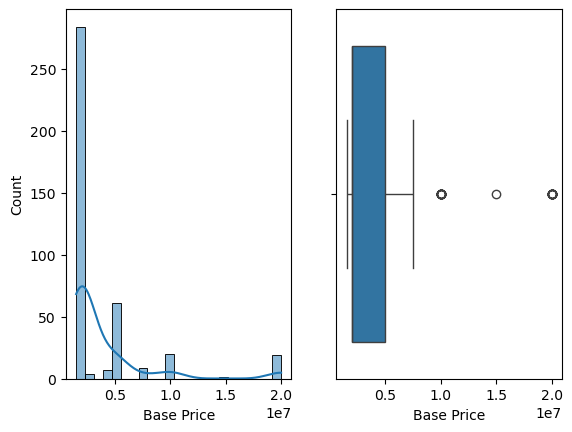

In [23]:
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    fig, axes= plt.subplots(nrows=1, ncols=2)
    sns.histplot(df[col], kde=True, ax=axes[0])
    sns.boxplot(x=df[col], ax=axes[1])
    plt.show()

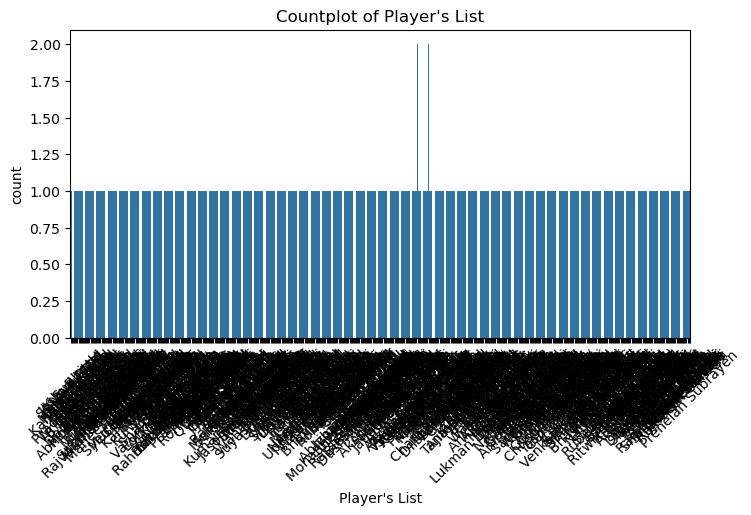

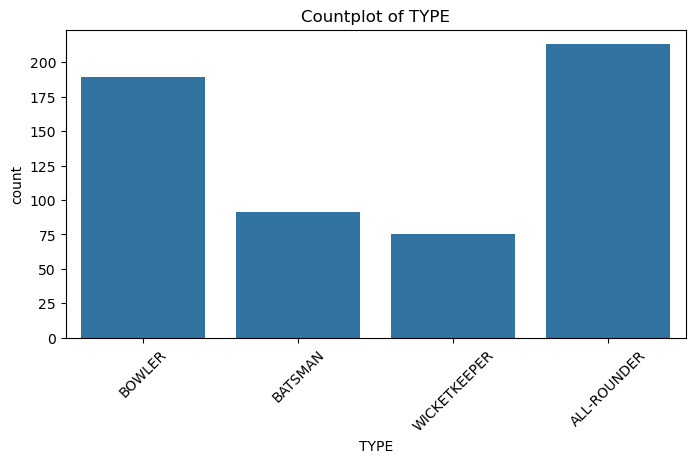

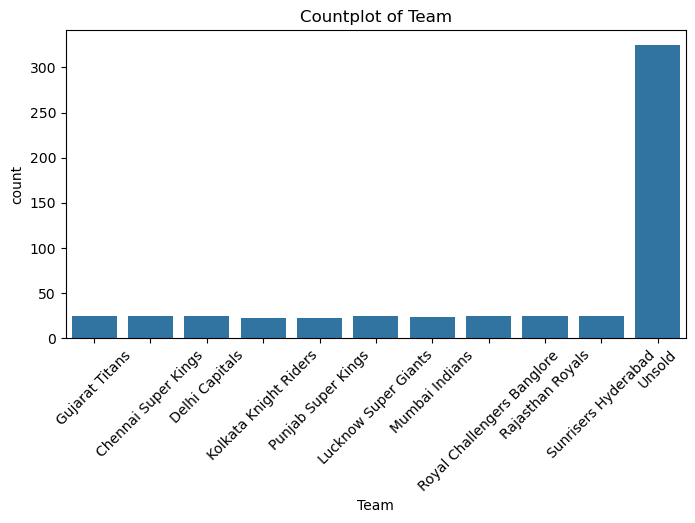

In [ ]:
cat_cols = df.select_dtypes(include="O").columns
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()


In [28]:
df.columns

Index(['Player's List', 'Base Price', 'TYPE', 'Team'], dtype='object')

#### Analysis Questions

##### How many players were acquired by each team?

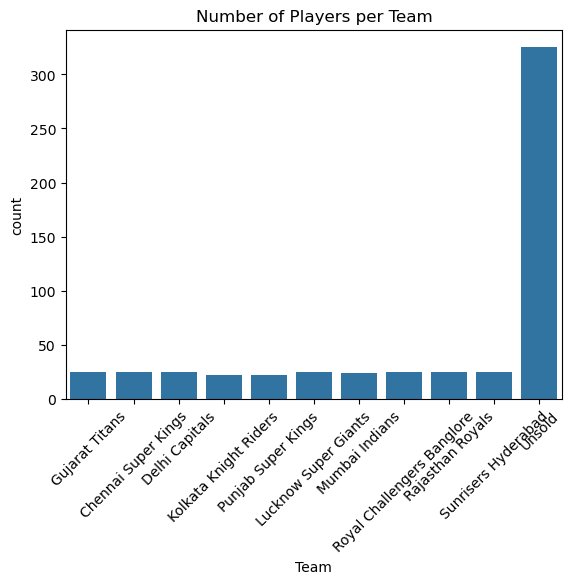

In [29]:
sns.countplot(x="Team", data=df)
plt.xticks(rotation=45)
plt.title("Number of Players per Team")
plt.show()


##### What does the spread of base prices look like?

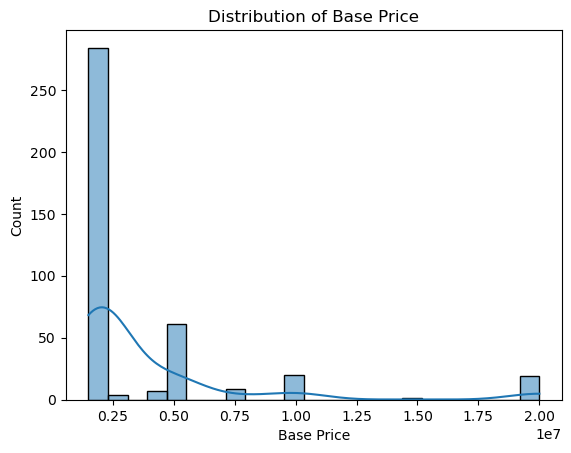

In [30]:
sns.histplot(df["Base Price"], kde=True)
plt.title("Distribution of Base Price")
plt.show()


##### Do batsmen, bowlers, all-rounders, or wicketkeepers have higher base prices on average?

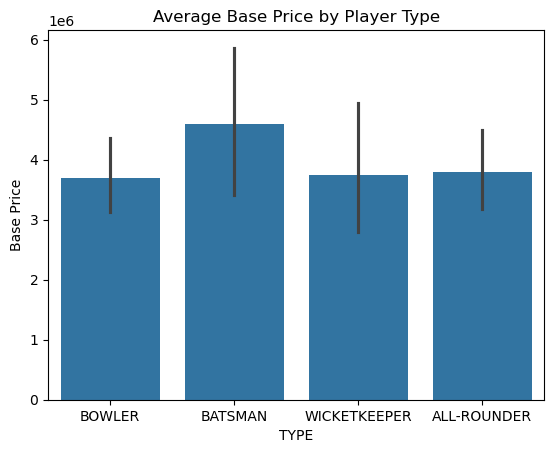

In [31]:
sns.barplot(x="TYPE", y="Base Price", data=df, estimator="mean")
plt.title("Average Base Price by Player Type")
plt.show()


#####  How are different player types distributed across teams?


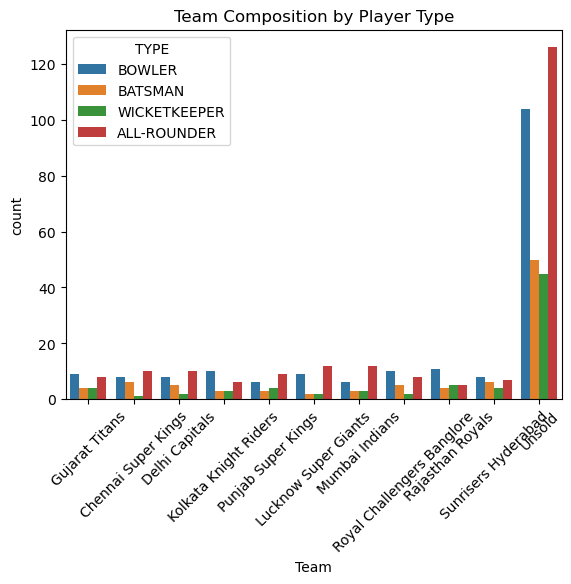

In [32]:
sns.countplot(x="Team", hue="TYPE", data=df)
plt.xticks(rotation=45)
plt.title("Team Composition by Player Type")
plt.show()


##### Who are the players with the highest base prices?

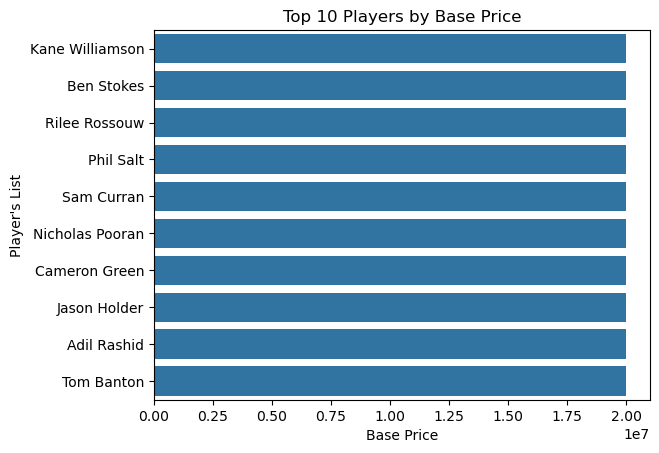

In [33]:
top_players = df.nlargest(10, "Base Price")
sns.barplot(x="Base Price", y="Player's List", data=top_players)
plt.title("Top 10 Players by Base Price")
plt.show()
